### [Uplift Modeling for Better ROI](https://medium.com/causal-inference-methods-models-and-applications/uplift-modeling-for-better-roi-eb90d4c8875e)

In [1]:
!pip install -qq causalml duecredit econml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.5/91.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalml.dataset import synthetic_data

import warnings
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

y, X, T, _, _, e = synthetic_data(mode=1, n=5000, p=9, sigma=2.5)
df = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(X.shape[1])])
df["Y"] = y
df["T"] = T

display(df.sample(15))

,x1,x2,x3,x4,x5,x6,x7,x8,x9,Y,T
2721,0.970641,0.597408,0.007086,0.034130,0.147485,0.187573,0.767619,0.222766,0.969142,-2.883923,0
1465,0.849137,0.235642,0.935162,0.954908,0.958905,0.837563,0.363825,0.072684,0.568819,2.244426,0
3157,0.693355,0.272593,0.456038,0.297139,0.150022,0.291178,0.580092,0.825970,0.363529,5.521254,1
1972,0.126621,0.369753,0.738557,0.293917,0.574703,0.415560,0.117764,0.330287,0.724871,5.620822,0
3915,0.437351,0.755803,0.164234,0.064559,0.836029,0.617274,0.176579,0.806305,0.658129,3.420103,1
3652,0.059301,0.972147,0.008247,0.945594,0.548048,0.702445,0.187133,0.654212,0.881958,3.309062,0
1802,0.980592,0.804559,0.860017,0.359637,0.324887,0.517048,0.045727,0.945358,0.143785,2.605891,0
4620,0.322184,0.420432,0.931221,0.707084,0.327459,0.179279,0.618478,0.657576,0.483623,4.793852,1
3639,0.807246,0.896923,0.787918,0.848499,0.101881,0.924065,0.624301,0.869218,0.684437,-0.748343,0
4671,0.149693,0.548469,0.898779,0.688227,0.135799,0.116090,0.911450,0.487610,0.923673,2.656128,1


In [3]:
feature_cols = ['x1','x2','x3','x4','x5','x6','x7','x8','x9']
outcome_col = 'Y'
treat_col = 'T'

df.groupby(treat_col)['Y'].agg(['count','mean'])

,count,mean
T,,
0,2392,1.143918
1,2608,1.978426


In [4]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df,test_size=0.3, random_state=42, stratify=df["T"])

display(df_train.head())

,x1,x2,x3,x4,x5,x6,x7,x8,x9,Y,T
1521,0.794352,0.490478,0.039806,0.763019,0.168569,0.631474,0.085664,0.946867,0.291724,1.437648,1
1249,0.874252,0.171011,0.425869,0.187173,0.773304,0.474373,0.351144,0.361100,0.852214,0.855153,1
4177,0.985538,0.875774,0.296403,0.507946,0.230841,0.514504,0.683332,0.085521,0.870117,4.092421,0
1981,0.653290,0.233996,0.183662,0.009954,0.471643,0.428646,0.233868,0.053652,0.429256,-2.971717,1
3555,0.558097,0.839283,0.762909,0.118656,0.245554,0.026658,0.007961,0.224375,0.799321,1.896177,1


In [5]:
from causalml.inference.meta import BaseTRegressor
from sklearn.linear_model import LinearRegression

# Initialize Learner with any base learner
learner = BaseTRegressor(learner=LinearRegression())

# Fit the model
learner.fit(X=df_train[feature_cols], treatment=df_train[treat_col], y=df_train[outcome_col])

# Predict uplift
uplift_hat_m1 = learner.predict(df_test[feature_cols])

display(uplift_hat_m1)

array([[0.791],
       [0.585],
       [0.622],
       ...,
       [0.713],
       [0.847],
       [0.826]])

In [6]:
def deciles(
    df_scored: pd.DataFrame,
    uplift_hat,
    decile_col: str = "decile",
    treat_col: str = "T",
    outcome_col: str = "Y", # Y is continuous (e.g., revenue or count)
    uplift_pred_col: str = "uplift_hat"
):
    df = df_scored.copy()
    q = 10
    df[uplift_pred_col] = uplift_hat

    # Rank and assign deciles (1 = highest predicted uplift)
    rank = df[uplift_pred_col].rank(method="first", ascending=False)
    df[decile_col] = (pd.qcut(rank, q=q, labels=False) + 1).astype(int)

    grouped = df.groupby(decile_col, sort=True)

    # Base counts
    base = grouped.agg(
        n=(outcome_col, "size"),
        n_treated=(treat_col, lambda s: int((s == 1).sum()))
    ).sort_index()
    base["n_untreated"] = base["n"] - base["n_treated"]

    # Treated/untreated mean outcome per decile (explicit means)
    means = (
        df.groupby([decile_col, treat_col])[outcome_col]
          .mean()
          .unstack(fill_value=np.nan)
          .rename(columns={0: "untreated_Y", 1: "treated_Y"})
          .sort_index().round(2)
    )

    # Join and compute actual uplift (= mean difference)
    summary = (
        base.join(means, how="left")
            .join(grouped[uplift_pred_col].mean().rename("uplift_pred"), how="left")
            .reset_index()
            .sort_values(decile_col).round(2)
    )
    summary["uplift"] = summary["treated_Y"] - summary["untreated_Y"]

    # Incremental outcome units per decile
    summary["incre_sum"] = summary["uplift"] * summary["n_treated"]

    # Cumulative metrics for the uplift curve
    summary["cum_incre_ttl"] = summary["incre_sum"].cumsum()
    summary["cum_n"] = summary["n"].cumsum()
    total_n = summary["n"].sum()
    summary["cum_coverage"] = summary["cum_n"] / total_n  # in [0,1]
    total_incremental_units = summary["incre_sum"].sum()

    return summary, df

summary_m1, test_scored_m1 = deciles(
    df_scored=df_test,
    uplift_hat=uplift_hat_m1)

display(summary_m1)

,decile,n,n_treated,n_untreated,untreated_Y,treated_Y,uplift_pred,uplift,incre_sum,cum_incre_ttl,cum_n,cum_coverage
0,1,150,105,45,1.02,2.16,1.16,1.14,119.70,119.70,150,0.1
1,2,150,121,29,1.11,2.16,0.95,1.05,127.05,246.75,300,0.2
2,3,150,100,50,2.15,2.49,0.84,0.34,34.00,280.75,450,0.3
3,4,150,100,50,1.32,1.68,0.76,0.36,36.00,316.75,600,0.4
4,5,150,90,60,1.68,1.92,0.69,0.24,21.60,338.35,750,0.5
5,6,150,79,71,0.84,1.89,0.61,1.05,82.95,421.30,900,0.6
6,7,150,60,90,0.94,1.59,0.54,0.65,39.00,460.30,1050,0.7
7,8,150,58,92,0.97,2.17,0.45,1.20,69.60,529.90,1200,0.8
8,9,150,44,106,1.21,1.99,0.34,0.78,34.32,564.22,1350,0.9
9,10,150,25,125,0.92,0.70,0.16,-0.22,-5.50,558.72,1500,1.0


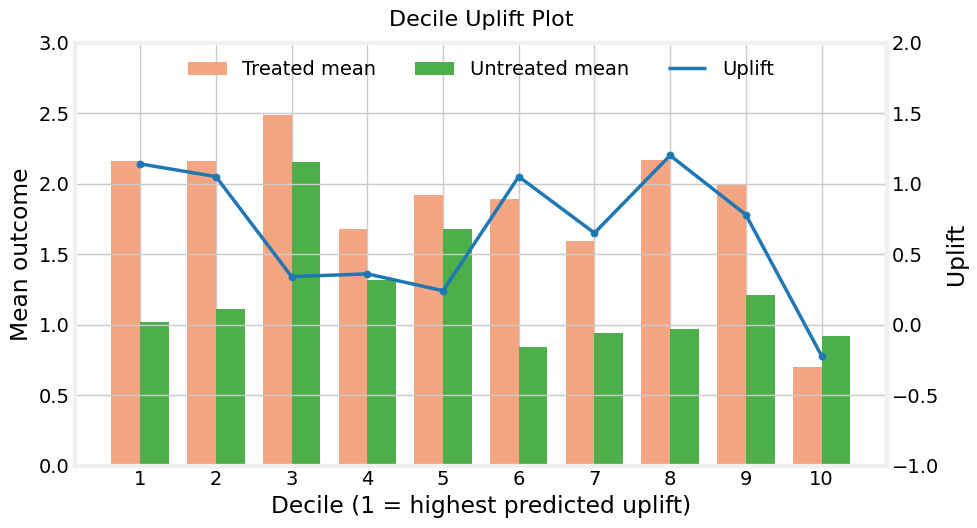

In [7]:
def plot_deciles(
    df: pd.DataFrame,
    decile_col: str = "decile",
    treated_col: str = "treated_Y",
    untreated_col: str = "untreated_Y",
    title: str = "Decile Uplift Plot"
):

    # Sort by decile to ensure left-to-right
    d = df.sort_values(decile_col).reset_index(drop=True)
    d[decile_col] = d[decile_col].astype(int)
    bin_labels = d[decile_col]

    treated = d[treated_col].astype(float).to_numpy()
    untreated = d[untreated_col].astype(float).to_numpy()
    uplift = treated - untreated

    # Positions for side-by-side bars
    n = len(bin_labels)
    x = np.arange(n)
    bar_width = 0.38

    # Colors
    color_treated = "#f4a582"   # peach
    color_untreated = "#4daf4a" # green
    color_line = "#1f77b4"      # blue

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="white")
    ax.set_facecolor("white")

    # Bars: treated vs. untreated mean outcome
    ax.bar(x - bar_width/2, treated, width=bar_width, label="Treated mean", color=color_treated)
    ax.bar(x + bar_width/2, untreated, width=bar_width, label="Untreated mean", color=color_untreated)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_xlabel("Decile (1 = highest predicted uplift)")
    ax.set_ylabel("Mean outcome")
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0,3)

    # Uplift line on right y-axis (treated - untreated)
    ax2 = ax.twinx()
    ax2.plot(x, uplift, color=color_line, linewidth=2.5, label="Uplift")
    ax2.scatter(x, uplift, color=color_line, s=26)
    ax2.set_ylabel("Uplift")
    ax2.set_ylim(-1,2)

    # Legend combining both axes
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc="upper center", ncol=3, frameon=False)

    plt.tight_layout()
    plt.show()

plot_deciles(
    df=summary_m1,
    decile_col="decile",
    treated_col="treated_Y",
    untreated_col="untreated_Y",
    title="Decile Uplift Plot"
)

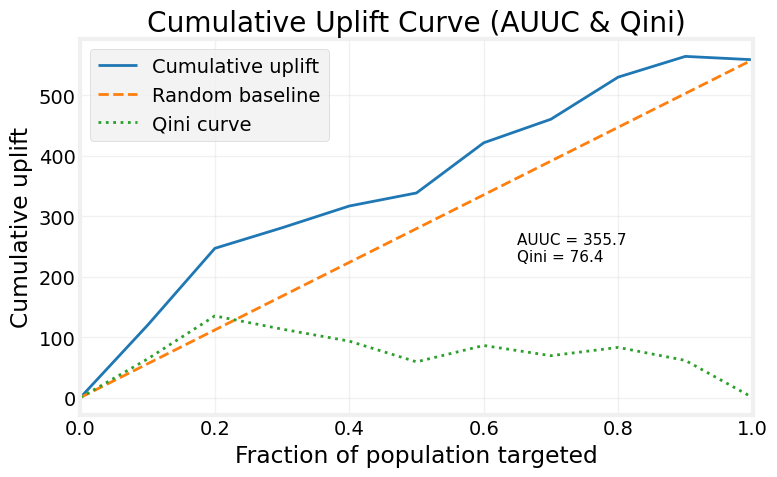

AUUC: 355.73800000000006
Qini: 76.378


In [8]:
def auuc_qini(
    decile_df: pd.DataFrame,
    coverage_col: str = "cum_coverage",
    cum_uplift_col: str = "cum_incre_ttl",
    title: str = "Cumulative Uplift Curve (AUUC & Qini)"
):

    # Ensure sorted by coverage (left to right)
    d = decile_df.sort_values(coverage_col).reset_index(drop=True)

    # X and Y for the curve
    x = d[coverage_col].to_numpy()
    y = d[cum_uplift_col].to_numpy()

    # Guard: ensure first point starts at 0 coverage & 0 uplift (optional, but typical)
    # If not, prepend a zero point to anchor the curve.
    if len(x) == 0 or x[0] > 0.0 or y[0] != 0.0:
        x = np.insert(x, 0, 0.0)
        y = np.insert(y, 0, 0.0)

    # Total cumulative uplift at full coverage
    total_cum_uplift = float(y[-1])

    # Baseline: random targeting accumulates linearly with coverage
    baseline = x * total_cum_uplift

    # AUUC: area under the cumulative uplift curve
    auuc = float(np.trapz(y, x))

    # Qini: area between model curve and random baseline
    qini = float(np.trapz(y - baseline, x))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.plot(x, y, label="Cumulative uplift", color="#1f77b4", linewidth=2)
    ax.plot(x, baseline, label="Random baseline", color="#ff7f0e", linestyle="--", linewidth=2)
    ax.plot(x, y - baseline, label="Qini curve", color="#2ca02c", linestyle=":", linewidth=2)

    ax.set_xlabel("Fraction of population targeted")
    ax.set_ylabel("Cumulative uplift")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    # y-limit auto; you can set ax.set_ylim(bottom=0) if uplift is always non-negative
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    # Annotate AUUC/Qini in-plot
    ymin, ymax = float(np.nanmin(y)), float(np.nanmax(y))
    y_annot = ymin + 0.4 * (ymax - ymin) if ymax > ymin else 0.0
    ax.annotate(f"AUUC = {auuc:.1f}\nQini = {qini:.1f}",
                xy=(0.65, y_annot), fontsize=11)

    plt.tight_layout()
    plt.show()

    curve_df = pd.DataFrame({"coverage": x, "cum_uplift": y, "baseline": baseline})
    return {"AUUC": auuc, "Qini": qini, "curve_df": curve_df}

metrics = auuc_qini(
    decile_df=summary_m1,
    coverage_col="cum_coverage",
    cum_uplift_col="cum_incre_ttl",
    title="Cumulative Uplift Curve (AUUC & Qini)"
)

print(f"AUUC: {metrics['AUUC']}")
print(f"Qini: {metrics['Qini']}")

<Figure size 500x300 with 0 Axes>

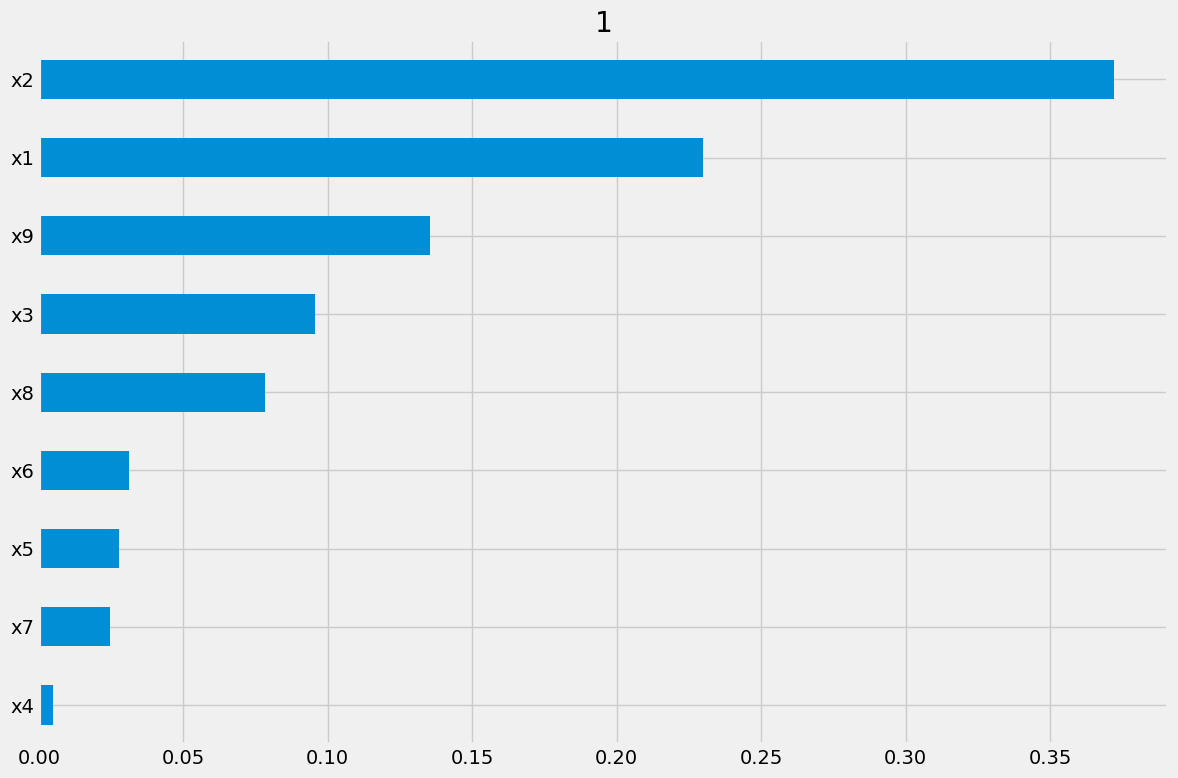

In [9]:
import sys
from sklearn.ensemble import GradientBoostingRegressor

model_tau_feature = GradientBoostingRegressor()

plt.figure(figsize=(5, 3))   # make it smaller; adjust as needed, e.g., (4, 2.5)
learner.plot_importance(
    X=df_test[feature_cols],
    tau=uplift_hat_m1,
    model_tau_feature=model_tau_feature,
    features=feature_cols,
    normalize=True,
    method='auto'
)

plt.tight_layout()
if "google.colab" not in sys.modules:
  plt.gcf().savefig("uplift_feature_importance.png", dpi=100, bbox_inches="tight")

plt.show()

plt.close()

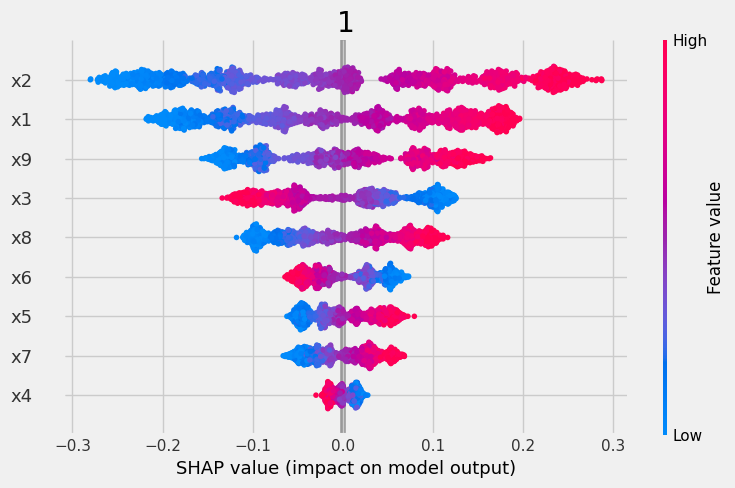

In [10]:
fig, ax = plt.subplots(figsize=(5, 3))
learner.plot_shap_values(
    X=df_test[feature_cols],
    model_tau_feature=model_tau_feature,
    features=feature_cols,
    tau=uplift_hat_m1
)
fig.tight_layout()
if "google.colab" not in sys.modules:
  fig.savefig("uplift_shap.png", dpi=150, bbox_inches="tight")

plt.show()

In [11]:
# Define the learners
model_treated = LinearRegression()
model_control = LinearRegression()

# Fit treated model on T == 1
treated_group = df_train["T"] == 1
model_treated.fit(df_train.loc[treated_group, feature_cols], df_train.loc[treated_group, "Y"])

# Fit control model on T == 0
control_group = df_train["T"] == 0
model_control.fit(df_train.loc[control_group, feature_cols], df_train.loc[control_group, "Y"])

# Predict potential outcomes for test set
mu1_hat = model_treated.predict(df_test[feature_cols])  # E[Y|T=1, X]
mu0_hat = model_control.predict(df_test[feature_cols])  # E[Y|T=0, X]

# Compute uplift
uplift_hat_m2 = mu1_hat - mu0_hat

# Check first few predictions
print("Predicted uplift:", uplift_hat_m2[:10])

Predicted uplift: [0.791 0.585 0.622 0.715 0.716 0.787 0.633 0.505 0.981 0.669]


In [12]:
summary_m2, test_scored_m2 = deciles(
    df_scored=df_test,
    uplift_hat=uplift_hat_m2)

display(summary_m2)

,decile,n,n_treated,n_untreated,untreated_Y,treated_Y,uplift_pred,uplift,incre_sum,cum_incre_ttl,cum_n,cum_coverage
0,1,150,105,45,1.02,2.16,1.16,1.14,119.70,119.70,150,0.1
1,2,150,121,29,1.11,2.16,0.95,1.05,127.05,246.75,300,0.2
2,3,150,100,50,2.15,2.49,0.84,0.34,34.00,280.75,450,0.3
3,4,150,100,50,1.32,1.68,0.76,0.36,36.00,316.75,600,0.4
4,5,150,90,60,1.68,1.92,0.69,0.24,21.60,338.35,750,0.5
5,6,150,79,71,0.84,1.89,0.61,1.05,82.95,421.30,900,0.6
6,7,150,60,90,0.94,1.59,0.54,0.65,39.00,460.30,1050,0.7
7,8,150,58,92,0.97,2.17,0.45,1.20,69.60,529.90,1200,0.8
8,9,150,44,106,1.21,1.99,0.34,0.78,34.32,564.22,1350,0.9
9,10,150,25,125,0.92,0.70,0.16,-0.22,-5.50,558.72,1500,1.0


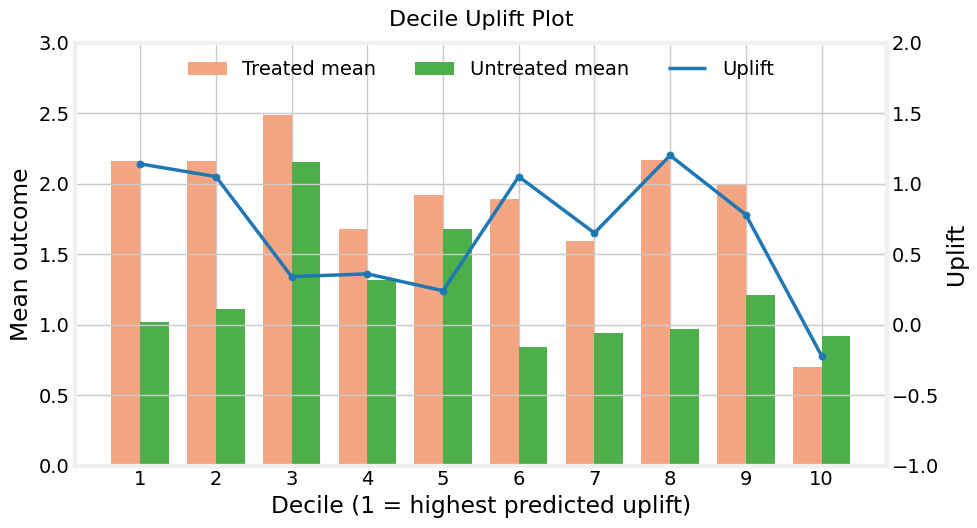

In [13]:
plot_deciles(
    df=summary_m2,
    decile_col="decile",
    treated_col="treated_Y",
    untreated_col="untreated_Y",
    title="Decile Uplift Plot"
)

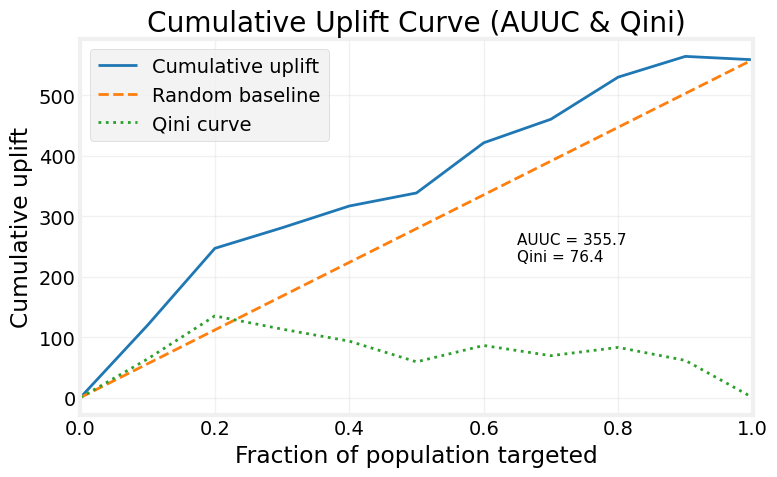

'AUUC: 355.73800000000006'

'Qini: 76.378'

In [14]:
metrics = auuc_qini(
    decile_df=summary_m2,
    coverage_col="cum_coverage",
    cum_uplift_col="cum_incre_ttl",
    title="Cumulative Uplift Curve (AUUC & Qini)"
)

display(f'AUUC: {metrics["AUUC"]}')
display(f'Qini: {metrics["Qini"]}')

In [15]:
from econml.metalearners import SLearner
from sklearn.ensemble import GradientBoostingRegressor

# 1) Instantiate the base model (don't pass the class itself)
overall_model =GradientBoostingRegressor(random_state=42)

# 2) Build and fit the S-Learner
s_learner = SLearner(overall_model=overall_model)
s_learner.fit(Y=df_train[outcome_col], T=df_train[treat_col], X=df_train[feature_cols])

# 3) Predict individual uplift (CATE) on the test set
uplift_hat_m3 = s_learner.effect(df_test[feature_cols])
print(uplift_hat_m3[:5])

[0.691 0.621 0.504 0.436 0.563]


In [16]:
# Decile Summary
summary_m3, test_scored_m3 = deciles(
    df_scored=df_test,
    uplift_hat=uplift_hat_m3)

display(summary_m3)

,decile,n,n_treated,n_untreated,untreated_Y,treated_Y,uplift_pred,uplift,incre_sum,cum_incre_ttl,cum_n,cum_coverage
0,1,150,102,48,0.89,1.79,0.80,0.90,91.80,91.80,150,0.1
1,2,150,95,55,1.15,1.77,0.69,0.62,58.90,150.70,300,0.2
2,3,150,90,60,1.58,2.59,0.62,1.01,90.90,241.60,450,0.3
3,4,150,97,53,1.32,1.92,0.57,0.60,58.20,299.80,600,0.4
4,5,150,97,53,0.95,2.01,0.52,1.06,102.82,402.62,750,0.5
5,6,150,83,67,1.14,2.33,0.48,1.19,98.77,501.39,900,0.6
6,7,150,62,88,1.50,1.88,0.42,0.38,23.56,524.95,1050,0.7
7,8,150,59,91,0.75,1.73,0.36,0.98,57.82,582.77,1200,0.8
8,9,150,61,89,1.10,1.74,0.27,0.64,39.04,621.81,1350,0.9
9,10,150,36,114,1.18,2.01,0.12,0.83,29.88,651.69,1500,1.0


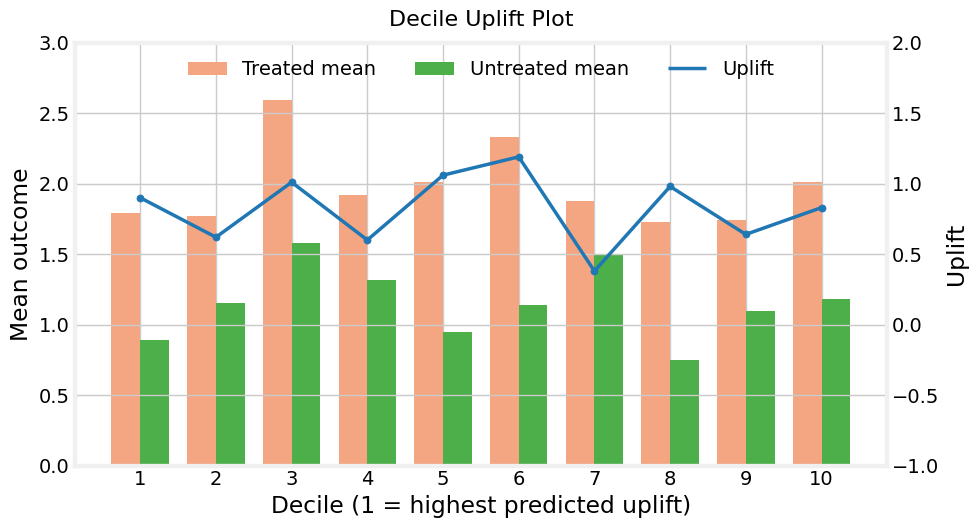

In [17]:
# Decile Uplift Plot
plot_deciles(
    df=summary_m3,
    decile_col="decile",
    treated_col="treated_Y",
    untreated_col="untreated_Y",
    title="Decile Uplift Plot"
)

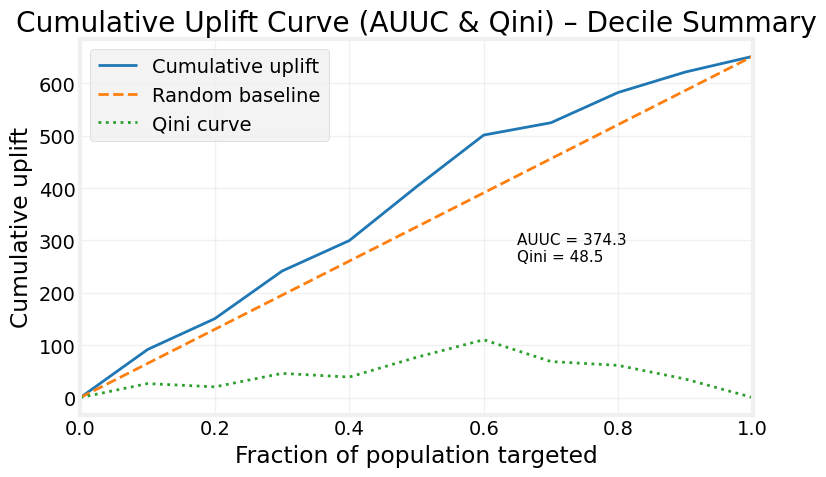

AUUC: 374.32849999999996
Qini: 48.4835


In [18]:
# Cumulative Uplift Curve (AUUC & Qini) Plot
metrics = auuc_qini(
    decile_df=summary_m3,
    coverage_col="cum_coverage",
    cum_uplift_col="cum_incre_ttl",
    title="Cumulative Uplift Curve (AUUC & Qini) – Decile Summary"
)

print(f"AUUC: {metrics['AUUC']}")
print(f"Qini: {metrics['Qini']}")